# Applied Statistics Project
*****

## Table of Contents
- [Introduction](#intro)
- [Imports](#imports)
- [Problem 1: Extending the Lady Tasting Tea](#prob_1)
- [Problem 2: Normal Distribution](#prob_2)
- [Problem 3: t-Tests](#prob_3)
- [Problem 4: ANOVA](#prob_4)
- [References](#refs)

## Introduction <a id="intro"></a>

This notebook contains solutions to four statistics problems. [Problem 1](#prob_1) is a variation of the [Lady Tasting Tea](https://archive.org/details/in.ernet.dli.2015.502684/page/n27/mode/1up) experiment, where the participant is presented with 12 cups of tea instead of 8. [Problem 2](#prob_2) compares two samples drawn from the standard normal distribution, where the standard deviation is computed with `ddof=1` for one sample, and with `ddof=0` for the other sample. [Problem 3](#prob_3) involves performing independent [t-tests](https://en.wikipedia.org/wiki/Student%27s_t-test) on normally distributed samples with varying mean difference <i>d</i> and examines how the rate of [type II errors](https://en.wikipedia.org/wiki/Type_I_and_type_II_errors) changes as <i>d</i> increases. [Problem 4](#prob_4) examines the difference between running one [ANOVA](https://researchmethod.net/anova/) test and running multiple t-tests.

## Imports <a id="imports"></a>

In [147]:
# Standard mathematical functions
# https://docs.python.org/3/library/math.html
import math

# Numerical structures and operations
# https://numpy.org/doc/stable/user/index.html#user
import numpy as np

# Permutations and combinations
# https://docs.python.org/3/library/itertools.html
import itertools

# Create plots
# https://matplotlib.org/stable/users/index.html
import matplotlib.pyplot as plt

# Statistical functions
# https://docs.scipy.org/doc/scipy/reference/stats.html
import scipy.stats as stats

# Data frames
# https://pandas.pydata.org/docs/user_guide/index.html
import pandas as pd

In [148]:
# create random number generator for problems 2 3 and 4
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.normal.html#numpy.random.Generator.normal
generator=np.random.default_rng()

## Problem 1: Extending the Lady Tasting Tea <a id="prob_1"></a>

The goal here is to extend the original [lady tasting tea experiment](https://archive.org/details/in.ernet.dli.2015.502684/page/n27/mode/1up) (<i>Fisher, 1935</i>), where a participant is presented with a set of randomly-shuffled cups of tea and claims to be able to tell which cups had the milk poured in before the tea. The original experiment used 8 cups of tea (4 with the tea poured first and 4 with the milk poured first). We are going to use 12 cups (8 tea-first and 4 milk-first), and calculate the probability of the participant correctly identifying the preparation method for each cup.

### Prepare the cups

In [149]:
# number of cups
n_cups = 12

# number of cups with milk added first
cups_milk_first = 4

# number of cups with tea added first
cups_tea_first = 8

### Calculating possible combinations

In mathematics, the choose function allows us to calculate the number of possible combinations when selecting <i>n</i> objects from a set of <i>k</i> objects  without order and without repetition i.e. each object can only be selected once.

![combination formula](https://wikimedia.org/api/rest_v1/media/math/render/svg/0f4e3f6d2dc3075f5569c82118fad11c32dff393)

#### Calculating possible combinations using math.factorial

The [math.factorial](https://docs.python.org/3/library/math.html#math.factorial) function allows us to easily make the calculations necessary for the choose function.

In [150]:
# total number of cups
n = 12

# number of cups with milk first
k = 4

In [151]:
math.factorial(n)

479001600

In [152]:
math.factorial(k)

24

In [153]:
math.factorial(n-k)

40320

In [154]:
# using the choose function
math.factorial(n)//(math.factorial(k)*math.factorial(n-k))

495

#### Calculating possible combinations using math.comb

The [math.comb](https://docs.python.org/3/library/math.html#math.comb) function condenses the above steps into one.

In [155]:
# number of possible combinations when selecting 8 cups from the 12 presented
combinations = math.comb(n_cups, cups_milk_first)
combinations

495

### Ordering the Results

In [156]:
#label the cups
labels = list(range(n_cups))
labels

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

In [157]:
# show how many unique ways there are of selecting cups_milk_first from n_cups
# https://docs.python.org/3/library/itertools.html#itertools.combinations
combs = list(itertools.combinations(labels, cups_milk_first))
len(combs)

495

In [158]:
# shuffle the prepared cups
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.shuffle.html
np.random.shuffle(labels)
labels

[9, 10, 1, 8, 7, 6, 11, 3, 5, 4, 2, 0]

In [159]:
# select 4 cups
# https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html
choice = np.random.choice(labels, size = 4, replace = False)
choice

array([8, 9, 1, 3])

In [160]:
# calculate the overlap between each element of combs and choice
overlaps_amount = []
# https://wiki.python.org/moin/ForLoop
for comb in combs:
    # Turn comb into a set
    set1 = set(comb)
    # Turn choice into a set
    set2 = set(choice)
    # See if they overlap
    overlap = set1.intersection(set2)
    # Append the overlap to overlaps_amount
    overlaps_amount.append(len(overlap))

In [161]:
count = np.unique(overlaps_amount, return_counts = True)
count

(array([0, 1, 2, 3, 4]), array([ 70, 224, 168,  32,   1]))

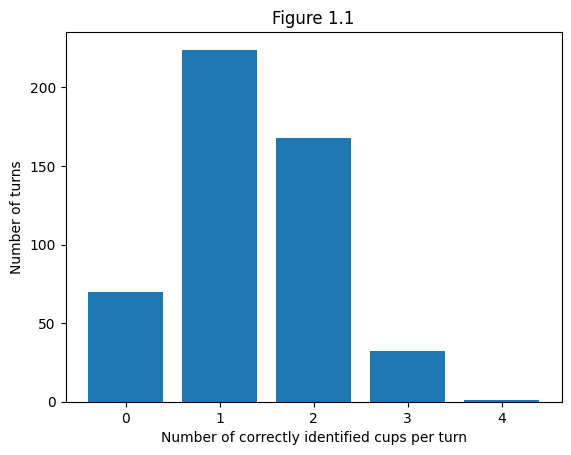

In [162]:
fig, ax = plt.subplots()
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html
ax.bar(count[0], count[1])
ax.set_title("Figure 1.1")
ax.set_xlabel("Number of correctly identified cups per turn")
ax.set_ylabel("Number of turns");

### Null Hypothesis

1. The participant has no special ability to discern the preparation method for each cup
2. The participant is selecting 4 cups at random and declaring them to have been prepared with the milk added before the tea infusion.

### Alternate Hypothesis

1. The participant is able to identify the cups which were prepared with the milk added before the tea infusion.

The probability that the participant will correctly identify the 4 cups with milk added first is 1/495, if they are selecting cups at random. If they do select the correct 4 cups, it is so unlikely that they would have done this by random chance that there is likely something non-random happening when they are making their selection.

In [163]:
# probability of participant randomly selecting 4 correct cups
1/495

0.00202020202020202

In [164]:
# probability of randomly selecting at least 3 correct cups
(32+1)/495

0.06666666666666667

## Problem 2: Normal Distribution <a id="prob_2"></a>

This problem begins with generating 100,000 samples of size 10 from the standard normal distribution. We then compute the standard deviation with two different [degrees of freedom](https://en.wikipedia.org/wiki/Degrees_of_freedom_(statistics)), 0 and 1.

In [165]:
ddof0=[]
ddof1=[]
for s in range(0,100000): #run loop 100,000 times
    # generate sample of size 10 
    samples=generator.normal(size=10)
    # calculate standard deviation with ddof=0 https://numpy.org/doc/stable/reference/generated/numpy.std.html
    samples_ddof0=np.std(samples,ddof=0)
    # calculate standard deviation with ddof=1
    samples_ddof1=np.std(samples,ddof=1)
    # add standard deviation values to ddof0 and ddof1
    ddof0.append(samples_ddof0)
    ddof1.append(samples_ddof1)

Once we have the values for `ddof=0` and `ddof=1`, we plot histograms of both sets of values on the same axes with transparency.

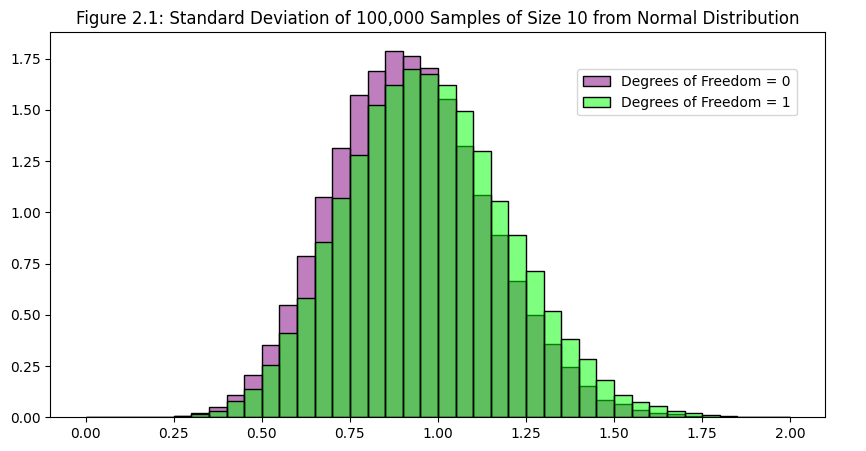

In [166]:
fig,ax=plt.subplots(figsize=(10,5))
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html#matplotlib-pyplot-hist
# transparent bars: https://stackoverflow.com/questions/28398200/plotting-transparent-histogram-with-non-transparent-edge
ax.hist(ddof0, edgecolor='black', density=True, bins=np.linspace(0,2,41), fc=(0.5,0,0.5,0.5), label='Degrees of Freedom = 0')
ax.hist(ddof1, edgecolor='black', density=True, bins=np.linspace(0,2,41), fc=(0,1,0,0.5), label='Degrees of Freedom = 1')
fig.legend(borderaxespad=5) # keep legend inside plot: https://stackoverflow.com/questions/57926148/how-to-keep-legends-inside-plot
ax.set_title('Figure 2.1: Standard Deviation of 100,000 Samples of Size 10 from Normal Distribution');

SD with `ddof=1` are clustered around 0.95, `ddof=0` clustered around 0.9

In [167]:
ddof0_2=[]
ddof1_2=[]
for s in range(0,100000): #run loop 100,000 times
    # generate sample of size 100
    samples_2=generator.normal(size=100)
    # calculate standard deviation with ddof=0 
    samples_ddof0_2=np.std(samples_2,ddof=0)
    # calculate standard deviation with ddof=1
    samples_ddof1_2=np.std(samples_2,ddof=1)
    # add standard deviation values to ddof0 and ddof1
    ddof0_2.append(samples_ddof0_2)
    ddof1_2.append(samples_ddof1_2)

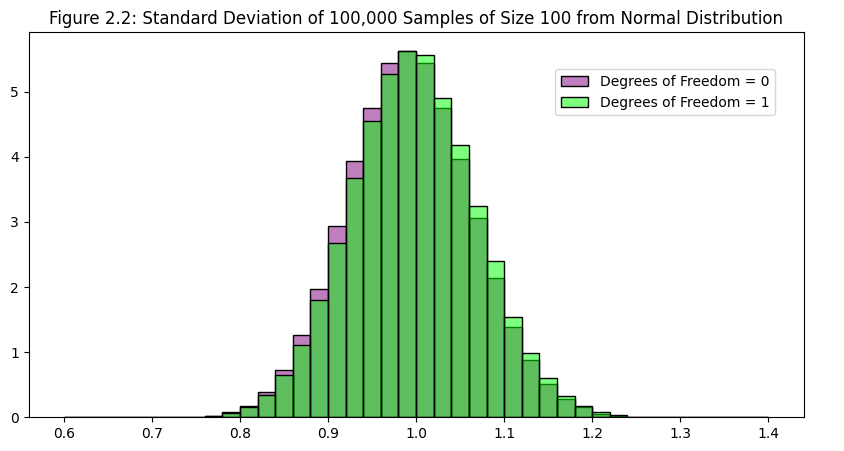

In [168]:
fig,ax=plt.subplots(figsize=(10,5))
ax.hist(ddof0_2, edgecolor='black', density=True, bins=np.linspace(0.6,1.4,41), fc=(0.5,0,0.5,0.5), label='Degrees of Freedom = 0')
ax.hist(ddof1_2, edgecolor='black', density=True, bins=np.linspace(0.6,1.4,41), fc=(0,1,0,0.5), label='Degrees of Freedom = 1')
fig.legend(borderaxespad=5)
ax.set_title('Figure 2.2: Standard Deviation of 100,000 Samples of Size 100 from Normal Distribution');

As we can see from Figure 2.2, increasing the sample size to 100 results in more of an overlap in the standard deviations of both groups of samples. The group which had SD calculated with `ddof=0` is clustered around 0.98, while the group with `ddof=1` is clustered around 1.0. The standard deviations themselves have increased, with both groups recording maximum standard deviations over 5, where the previous groups both had maximum standard deviations under 2.

## Problem 3: t-Tests <a id="prob_3"></a>

[T-tests](https://en.wikipedia.org/wiki/Student%27s_t-test) (also known as Student's t-tests) are commonly used to test whether the means of two populations are equal. One-sample t-tests are used to determine if the mean of a population is equal to a value specified in the null hypothesis. Paired sample t-tests are used to determine if the means of two related populations are equal, while independent sample t-tests determine if the means of two unrelated populations are equal.

Independent t-test formula:

![independent t-test formula](https://wikimedia.org/api/rest_v1/media/math/render/svg/09aab90a09d5dba053cb4e398f9999738c8ca5e3) where ![pooled standard deviation](https://wikimedia.org/api/rest_v1/media/math/render/svg/2adbe1794944e2924c113eacd348126a39746e59)

[Type II errors](https://en.wikipedia.org/wiki/Type_I_and_type_II_errors), also known as false negatives, occur when the null hypothesis is not rejected despite being false. In this problem, we generate 11 pairs of samples from the standard normal distribution, where one half of each pair is drawn from an unmodified normal distribution and the other has a specified mean difference <i>d</i> between 0 and 1. We then run independent t-tests on each pair 1,000 times, rejecting the null hypothesis if the p-value is below 0.05. We plot the type II error rate against <i>d</i> to see how the error rate changes as <i>d</i> increases.

In [169]:
d=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]

In [170]:
null_nr1=0
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_1=generator.normal(size=100)
    # samples with d=0
    samples_1=generator.normal(d[0],1,100)
    # independent t-test 
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html#scipy.stats.ttest_ind
    ttest1, pvalue1=stats.ttest_ind(ttest_1,samples_1)
    if pvalue1>=0.05:
        null_nr1+=1
y1=(null_nr1/1000)*100
print(f"Type II error percentage: {y1}%")

Type II error percentage: 95.39999999999999%


In [171]:
null_nr2=0
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_2=generator.normal(size=100)
    # samples with d=0.1
    samples_2=generator.normal(d[1],1,100)
    # independent t-test 
    ttest2, pvalue2=stats.ttest_ind(ttest_2,samples_2)
    if pvalue2>=0.05:
        null_nr2+=1
y2=(null_nr2/1000)*100
print(f"Type II error percentage: {y2}%")

Type II error percentage: 88.9%


In [172]:
null_nr3=0
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_3=generator.normal(size=100)
    # samples with d=0.2
    samples_3=generator.normal(d[2],1,100)
    # independent t-test 
    ttest3, pvalue3=stats.ttest_ind(ttest_3,samples_3)
    if pvalue3>=0.05:
        null_nr3+=1
y3=(null_nr3/1000)*100
print(f"Type II error percentage: {y3}%")

Type II error percentage: 71.3%


In [173]:
null_nr4=0
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_4=generator.normal(size=100)
    # samples with d=0.3
    samples_4=generator.normal(d[3],1,100)
    # independent t-test 
    ttest4, pvalue4=stats.ttest_ind(ttest_4,samples_4)
    if pvalue4>=0.05:
        null_nr4+=1
y4=(null_nr4/1000)*100
print(f"Type II error percentage: {y4}%")

Type II error percentage: 44.3%


In [174]:
null_nr5=0
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_5=generator.normal(size=100)
    # samples with d=0.4
    samples_5=generator.normal(d[4],1,100)
    # independent t-test 
    ttest5, pvalue5=stats.ttest_ind(ttest_5,samples_5)
    if pvalue5>=0.05:
        null_nr5+=1
y5=(null_nr5/1000)*100
print(f"Type II error percentage: {y5}%")

Type II error percentage: 21.6%


In [175]:
null_nr6=0
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_6=generator.normal(size=100)
    # samples with d=0.5
    samples_6=generator.normal(d[5],1,100)
    # independent t-test 
    ttest6, pvalue6=stats.ttest_ind(ttest_6,samples_6)
    if pvalue6>=0.05:
        null_nr6+=1
y6=(null_nr6/1000)*100
print(f"Type II error percentage: {y6}%")

Type II error percentage: 5.5%


In [176]:
null_nr7=0
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_7=generator.normal(size=100)
    # samples with d=0.6
    samples_7=generator.normal(d[6],1,100)
    # independent t-test 
    ttest7, pvalue7=stats.ttest_ind(ttest_7,samples_7)
    if pvalue7>=0.05:
        null_nr7+=1
y7=(null_nr7/1000)*100
print(f"Type II error percentage: {y7}%")

Type II error percentage: 1.6%


In [177]:
null_nr8=0
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_8=generator.normal(size=100)
    # samples with d=0.7
    samples_8=generator.normal(d[7],1,100)
    # independent t-test 
    ttest8, pvalue8=stats.ttest_ind(ttest_8,samples_8)
    if pvalue8>=0.05:
        null_nr8+=1
y8=(null_nr8/1000)*100 
print(f"Type II error percentage: {y8}%")       

Type II error percentage: 0.2%


In [178]:
null_nr9=0
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_9=generator.normal(size=100)
    # samples with d=0.8
    samples_9=generator.normal(d[8],1,100)
    # independent t-test 
    ttest9, pvalue9=stats.ttest_ind(ttest_9,samples_9)
    if pvalue9>=0.05:
        null_nr9+=1
y9=(null_nr9/1000)*100
print(f"Type II error percentage: {y9}%")        

Type II error percentage: 0.0%


In [179]:
null_nr10=0
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_10=generator.normal(size=100)
    # samples with d=0.9
    samples_10=generator.normal(d[9],1,100)
    # independent t-test 
    ttest10, pvalue10=stats.ttest_ind(ttest_10,samples_10)
    if pvalue10>=0.05:
        null_nr10+=1
y10=(null_nr10/1000)*100  
print(f"Type II error percentage: {y10}%")      

Type II error percentage: 0.0%


In [180]:
null_nr11=0
for s in range (0,1000):
    # samples from standard normal distribution
    ttest_11=generator.normal(size=100)
    # samples with d=1
    samples_11=generator.normal(d[10],1,100)
    # independent t-test 
    ttest11, pvalue11=stats.ttest_ind(ttest_11,samples_11)
    if pvalue11>=0.05:
        null_nr11+=1
y11=(null_nr11/1000)*100
print(f"Type II error percentage: {y11}%")

Type II error percentage: 0.0%


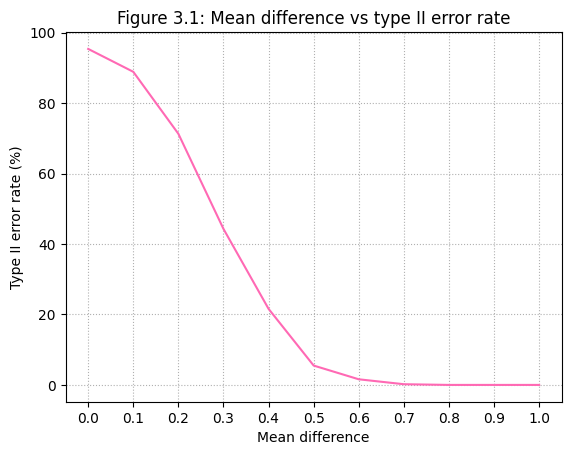

In [181]:
y_values=(y1,y2,y3,y4,y5,y6,y7,y8,y9,y10,y11)
fig,ax=plt.subplots()
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
ax.plot(d,y_values, color="hotpink")
ax.set_xticks(d)
ax.set_title("Figure 3.1: Mean difference vs type II error rate")
ax.set_xlabel("Mean difference")
ax.set_ylabel("Type II error rate (%)")
ax.grid(linestyle='dotted');

The type II error rate drops sharply as mean difference increases in 0.1 increments; after a mean difference of 0.8 the null hypothesis is always rejected.

## Problem 4: ANOVA <a id="prob_4"></a>

THis problem involves a comparison between [ANOVA](https://researchmethod.net/anova/) and [t-tests](https://en.wikipedia.org/wiki/Student%27s_t-test). We generate three normally-distributed samples of size 30, with means of 0, 0.5, and 1 respectively. We perform a one-ay ANOVa test on these samples to see if the means are different, and then perform independent t-tests on samples 1 and 2, 1 and 3, and 2 and 3. We then compare the conclusions.

In [182]:
# generate samples
anova_1=generator.normal(0,1,30)
anova_2=generator.normal(0.5,1,30)
anova_3=generator.normal(1,1,30)

In [183]:
# create data frame from samples
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html
df=pd.DataFrame({"Sample 1":anova_1, "Sample 2":anova_2, "Sample 3":anova_3})

In [184]:
# describe data frame
df.describe()

,Sample 1,Sample 2,Sample 3
count,30.000000,30.000000,30.000000
mean,-0.223596,0.360514,1.003831
std,0.963756,0.966563,1.072340
min,-2.366697,-1.388599,-0.737841
25%,-0.745171,-0.150742,0.091241
50%,-0.222656,0.280128,1.100366
75%,0.327813,0.899164,1.518546
max,2.031532,2.386637,3.773926


In [185]:
# perform one-way F test
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html
f_stat, p_anova=stats.f_oneway(df["Sample 1"], df["Sample 2"], df["Sample 3"])
f_stat, p_anova

(np.float64(11.259371148461522), np.float64(4.4806395857015886e-05))

ANOVA rejects the null hypothesis, showing that at least some of the samples are different.

In [186]:
# perform Tukey's HSD
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html
results=stats.tukey_hsd(df["Sample 1"], df["Sample 2"], df["Sample 3"])
print(results)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.584     0.067    -1.201     0.033
 (0 - 2)     -1.227     0.000    -1.844    -0.610
 (1 - 0)      0.584     0.067    -0.033     1.201
 (1 - 2)     -0.643     0.039    -1.260    -0.026
 (2 - 0)      1.227     0.000     0.610     1.844
 (2 - 1)      0.643     0.039     0.026     1.260



Tukey's HSD specifies that the null hypothesis is rejected when comparing sample 1 with sample 3, and that it is accepted when comparing sample 1 with sample 2 and sample 2 with sample 3.

In [187]:
# perform independent t-tests on same samples
tttest4_1, pvalue4_1=stats.ttest_ind(anova_1,anova_2)
ttest4_2, pvalue4_2=stats.ttest_ind(anova_1,anova_3)
ttest4_3, pvalue4_3=stats.ttest_ind(anova_2,anova_3)
print(pvalue4_1, pvalue4_2, pvalue4_3)

0.022530575704560005 1.8764879754637932e-05 0.017731931752622054


The three t-tests show the same result as the ANOVA; the null hypothesis is rejected when comparing sample 1 with sample 3, and is accepted when comparing sample 1 with sample 2 and sample 2 with sample 3.

Performing one ANOVA and one Tukey's HSD on multiple samples is more efficient than running multiple t-tests, particularly with high numbers of samples. It also has a reduced risk of [type I errors](https://en.wikipedia.org/wiki/Type_I_and_type_II_errors) compared to running multiple t-tests.

### References <a id="refs"></a>

1. Fisher, R. (1935). II. The principles of experimentation, illustrated by a psycho-physical experiment. <i>The Design of Experiments</i> 13-29. https://archive.org/details/in.ernet.dli.2015.502684/page/n27/mode/1up
1. [T-test](https://en.wikipedia.org/wiki/Student%27s_t-test)
1. [Type II and type II errors](https://en.wikipedia.org/wiki/Type_I_and_type_II_errors)
1. [ANOVA](https://researchmethod.net/anova/)
1. [math documentation](https://docs.python.org/3/library/math.html)
1. [NumPy documentation](https://numpy.org/doc/stable/user/index.html#user)
1. [itertools documentation](https://docs.python.org/3/library/itertools.html)
1. [Matplotlib documentation](https://matplotlib.org/stable/users/index.html)
1. [SciPy.stats documentation](https://docs.scipy.org/doc/scipy/reference/stats.html)
1. [pandas documentation](https://pandas.pydata.org/docs/user_guide/index.html)
1. [NumPy random number generator](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.normal.html#numpy.random.Generator.normal)
1. [Combination formula](https://wikimedia.org/api/rest_v1/media/math/render/svg/0f4e3f6d2dc3075f5569c82118fad11c32dff393)
1. [math.factorial documentation](https://docs.python.org/3/library/math.html#math.factorial)
1. [math.comb documentation](https://docs.python.org/3/library/math.html#math.comb)
1. [itertools.combinations documentation](https://docs.python.org/3/library/itertools.html#itertools.combinations)
1. [numpy.random.shuffle documentation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.shuffle.html)
1. [numpy.random.choice documentation](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html)
1. [For loop documentation](https://wiki.python.org/moin/ForLoop)
1. [matplotlib.pyplot.bar documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html)
1. [Degrees of freedom](https://en.wikipedia.org/wiki/Degrees_of_freedom_(statistics))
1. [numpy.std documentation](https://numpy.org/doc/stable/reference/generated/numpy.std.html)
1. [matplotlib.pyplot.hist documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html#matplotlib-pyplot-hist)
1. [How to plot a transparent histrogram with solid edges](https://stackoverflow.com/questions/28398200/plotting-transparent-histogram-with-non-transparent-edge)
1. [How to keep a legend inside a plot](https://stackoverflow.com/questions/57926148/how-to-keep-legends-inside-plot)
1. [Independent t-test formula](https://wikimedia.org/api/rest_v1/media/math/render/svg/09aab90a09d5dba053cb4e398f9999738c8ca5e3)
1. [Pooled standard deviation](https://wikimedia.org/api/rest_v1/media/math/render/svg/2adbe1794944e2924c113eacd348126a39746e59)
1. [scipy.stats.ttest_ind documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html#scipy.stats.ttest_ind)
1. [matplotlib.pyplot.plot documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)
1. [pandas.DataFrame documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html)
1. [pandas.DataFrame.describe documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html)
1. [scipy.stats.f_oneway documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html)
1. [scipy.stats.tukey_hsd documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html)

*****
# End